# Aprendizaje Automático
# Trabajo Práctico 2

Profesor: Juan Luis Crespo Mariño

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---


Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

BD utilizada: https://archive.ics.uci.edu/dataset/2/adult


Estudiante:
1. **Jose Pablo Ruiz Myrie**
2. **Nikole Villalobos Lopez**


# Notebook 07 — Modelo K-Vecinos más Cercanos (KNN)

En este notebook se entrena y evalúa un clasificador K-Vecinos más Cercanos
(KNN) para determinar si el ingreso anual de una persona supera los $50K. Se
utiliza el dataset `datos_finales.csv`, que ya contiene las variables
seleccionadas, imputadas, codificadas y escaladas en los notebooks anteriores,
incluyendo el tratamiento de outliers (transformación logarítmica de
`capital-gain` y `capital-loss`).

El escalado previo es especialmente importante para KNN, ya que este algoritmo
se basa en distancias entre observaciones: si las variables tuvieran escalas
muy distintas, aquellas con valores más grandes dominarían el cálculo de la
distancia. Al trabajar sobre `datos_finales.csv` el modelo se construye sobre
los mismos datos que el resto de modelos del proyecto y la comparación resulta
justa.


### División de los datos

El dataset se divide en tres conjuntos: 70% entrenamiento, 15% validación y 15% prueba. Esta distribución permite disponer de suficientes observaciones para entrenar y, al mismo tiempo, mantener conjuntos independientes para seleccionar y evaluar la mejor configuración.

- **Entrenamiento (70%):** para ajustar el KNN en sus distintas configuraciones de hiperparámetros.
- **Validación (15%):** para comparar las combinaciones de hiperparámetros y seleccionar la de mejor desempeño.
- **Prueba (15%):** se utiliza únicamente al final para evaluar el modelo ganador sobre datos no vistos.

### Diseño del estudio de hiperparámetros

KNN clasifica cada observación según la clase mayoritaria de sus K vecinos más cercanos. No construye un modelo explícito durante el entrenamiento, sino que almacena los datos y calcula distancias en el momento de predecir. Para estudiar su comportamiento de forma controlada se modifican los siguientes hiperparámetros:

- **Número de vecinos (n_neighbors):** cantidad de vecinos considerados para votar la clase. Un valor muy pequeño hace al modelo sensible al ruido (riesgo de sobreajuste), mientras que un valor muy grande suaviza demasiado la frontera de decisión y puede subajustar.
- **Ponderación de los vecinos (weights):** con `uniform` todos los vecinos pesan igual; con `distance` los vecinos más cercanos pesan más que los lejanos, lo que puede ayudar cuando la densidad de puntos es irregular.

Se comparan cinco configuraciones representativas frente al modelo base (k=5, el valor por defecto de scikit-learn). Para evaluar el desempeño se utilizan accuracy, precision, recall, F1 y AUC-ROC, métricas en las que un valor mayor indica un mejor resultado. La selección del mejor modelo se realiza exclusivamente sobre el conjunto de validación usando F1, y el conjunto de prueba se reserva para la evaluación final.

In [1]:
# ============================================================
# Preparación de los datos e importe de librerías
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# -----------------------------------------------------------
# 1. Cargamos los datos
# -----------------------------------------------------------

# Usamos datos_finales.csv, que ya incluye el preprocesado completo
# (imputación, tratamiento de outliers, codificación y escalado)
df = pd.read_csv("../data/datos_finales.csv")

print("Dimensiones del dataset:")
print(df.shape)
df.head()

Dimensiones del dataset:
(48842, 82)


,age,education-num,capital-gain-log,capital-loss-log,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,-0.119879,1.136512,-0.297918,-0.221264,-2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,1.265933,-0.808297,-0.297918,4.450068,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.047121,-0.419335,-0.297918,-0.221264,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,2.432933,-1.197259,-0.297918,-0.221264,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.536558,1.525474,-0.297918,-0.221264,-0.4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [3]:
# -----------------------------------------------------------
# 2. Separamos variables predictoras y variable objetivo
# -----------------------------------------------------------

# El archivo datos_finales ya contiene las variables predictoras
# imputadas, codificadas y escaladas (indispensable para KNN)
X_model = df.drop(columns=["income"])

# La variable objetivo ya se encuentra codificada como 0 = <=50K y 1 = >50K
y_model = df["income"]


# -----------------------------------------------------------
# 3. Separación de entrenamiento, validación y prueba
# -----------------------------------------------------------

# Separamos en 70% entrenamiento y 30% temporal para validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42,
    stratify=y_model
)

# Dividimos el 30% temporal en 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [4]:
# -----------------------------------------------------------
# 4. KNN Baseline
# -----------------------------------------------------------

# Modelo base con el valor por defecto de scikit-learn (k=5). Sirve como punto
# de referencia para comparar el efecto de los hiperparámetros.
knn_baseline = KNeighborsClassifier(n_neighbors=5)

# Entrenamiento
knn_baseline.fit(X_train, y_train)

# Predicciones sobre validación
y_pred_knn_baseline = knn_baseline.predict(X_val)
y_prob_knn_baseline = knn_baseline.predict_proba(X_val)[:, 1]


# -----------------------------------------------------------
# 5. Evaluación del modelo baseline
# -----------------------------------------------------------

knn_baseline_metrics = {
    "Modelo": "KNN - Baseline (k=5)",
    "Accuracy": accuracy_score(y_val, y_pred_knn_baseline),
    "Precision": precision_score(y_val, y_pred_knn_baseline),
    "Recall": recall_score(y_val, y_pred_knn_baseline),
    "F1": f1_score(y_val, y_pred_knn_baseline),
    "AUC-ROC": roc_auc_score(y_val, y_prob_knn_baseline)
}

for metric, value in knn_baseline_metrics.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")

Accuracy: 0.8296
Precision: 0.6507
Recall: 0.6218
F1: 0.6359
AUC-ROC: 0.8602


In [5]:
# -----------------------------------------------------------
# 6. Ajuste de hiperparámetros
# -----------------------------------------------------------

# Definimos cinco configuraciones diferentes para analizar el efecto del número
# de vecinos y de la ponderación sobre el rendimiento

knn_configurations = [

    {
        "Modelo": "KNN k=15 uniform",
        "n_neighbors": 15,
        "weights": "uniform"
    },

    {
        "Modelo": "KNN k=25 distance",
        "n_neighbors": 25,
        "weights": "distance"
    },

    {
        "Modelo": "KNN k=51 uniform",
        "n_neighbors": 51,
        "weights": "uniform"
    },

    {
        "Modelo": "KNN k=35 distance",
        "n_neighbors": 35,
        "weights": "distance"
    },

    {
        "Modelo": "KNN k=75 uniform",
        "n_neighbors": 75,
        "weights": "uniform"
    }
]


# Creamos una lista para almacenar los resultados
knn_results = []

# Incluimos primero los resultados del baseline
knn_results.append(knn_baseline_metrics)

# Creamos un diccionario para almacenar los modelos entrenados
knn_models = {
    "KNN - Baseline (k=5)": knn_baseline
}


# -----------------------------------------------------------
# 7. Entrenamos cada configuración
# -----------------------------------------------------------

for config in knn_configurations:

    knn_model = KNeighborsClassifier(
        n_neighbors=config["n_neighbors"],
        weights=config["weights"]
    )

    # Entrenamiento
    knn_model.fit(X_train, y_train)

    # Predicciones sobre validación
    y_pred = knn_model.predict(X_val)
    y_prob = knn_model.predict_proba(X_val)[:, 1]

    # Calculamos las métricas
    metrics = {
        "Modelo": config["Modelo"],
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_prob)
    }

    knn_results.append(metrics)

    # Guardamos el modelo entrenado
    knn_models[config["Modelo"]] = knn_model


# -----------------------------------------------------------
# 8. Comparación de resultados
# -----------------------------------------------------------

knn_results_df = pd.DataFrame(knn_results)

print("\nComparación de modelos (conjunto de validación):")
display(knn_results_df.round(4))

# Seleccionamos el mejor modelo según F1 sobre validación
best_knn_name = knn_results_df.loc[knn_results_df["F1"].idxmax(), "Modelo"]
best_knn_model = knn_models[best_knn_name]

print("\nMejor modelo según F1:")
print(best_knn_name)


Comparación de modelos (conjunto de validación):


,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC
0,KNN - Baseline (k=5),0.8296,0.6507,0.6218,0.6359,0.8602
1,KNN k=15 uniform,0.8413,0.6817,0.6315,0.6556,0.8894
2,KNN k=25 distance,0.8325,0.6600,0.6189,0.6388,0.8560
3,KNN k=51 uniform,0.8436,0.6920,0.6241,0.6563,0.8981
4,KNN k=35 distance,0.8340,0.6630,0.6229,0.6424,0.8556
5,KNN k=75 uniform,0.8429,0.6960,0.6098,0.6500,0.8979



Mejor modelo según F1:
KNN k=51 uniform



Resultados finales en prueba:
Accuracy: 0.8522
Precision: 0.7099
Recall: 0.6463
F1: 0.6766
AUC-ROC: 0.9052


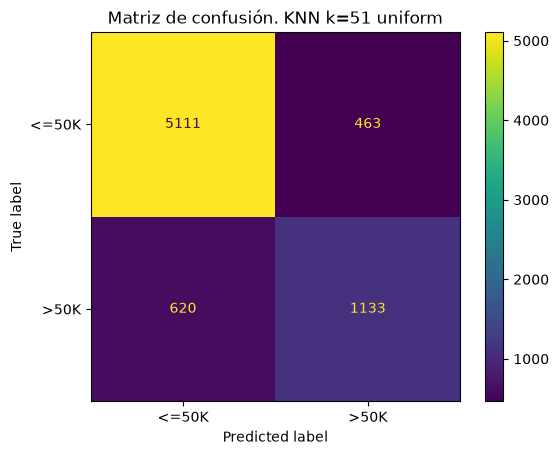

In [6]:
# -----------------------------------------------------------
# 9. Evaluación final en conjunto de prueba
# -----------------------------------------------------------

# El conjunto de prueba se utiliza únicamente después de seleccionar el
# mejor modelo mediante validación
y_pred_knn_test = best_knn_model.predict(X_test)
y_prob_knn_test = best_knn_model.predict_proba(X_test)[:, 1]

knn_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn_test),
    "Precision": precision_score(y_test, y_pred_knn_test),
    "Recall": recall_score(y_test, y_pred_knn_test),
    "F1": f1_score(y_test, y_pred_knn_test),
    "AUC-ROC": roc_auc_score(y_test, y_prob_knn_test)
}

print("\nResultados finales en prueba:")
for metric, value in knn_test_metrics.items():
    print(f"{metric}: {value:.4f}")


# -----------------------------------------------------------
# 10. Matriz de confusión del mejor modelo
# -----------------------------------------------------------

matriz_confusion_knn = confusion_matrix(y_test, y_pred_knn_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_knn,
    display_labels=["<=50K", ">50K"]
)

disp.plot()
plt.title(f"Matriz de confusión. {best_knn_name}")
plt.show()

### Análisis de resultados del modelo seleccionado como ganador

En este caso el modelo ganador resultó ser el KNN con k=51 y ponderación uniforme. Esta configuración obtuvo el mayor F1 sobre el conjunto de validación. El resultado es coherente con la teoría de KNN: un valor de k muy pequeño (como el baseline k=5) hace al modelo sensible al ruido, mientras que un valor de k más alto suaviza la frontera de decisión y mejora la generalización, siempre que no sea tan grande como para subajustar.

Al evaluar el modelo seleccionado sobre el conjunto de prueba se obtuvo una exactitud de 85.22%, lo que quiere decir que el modelo clasificó correctamente aproximadamente 85 de cada 100 observaciones. Debido al desequilibrio entre las clases, la exactitud por sí sola no es suficiente, por lo que también se consideran precision, recall, F1 y AUC-ROC. La precisión fue de 70.99%, lo que significa que del total de personas que el modelo clasificó como individuos con ingresos superiores a $50K, alrededor del 71% pertenecía realmente a esa categoría. El recall fue de 64.63%, es decir, el modelo identificó correctamente cerca del 65% de todas las observaciones que realmente superaban los $50K. El F1 de 0.6766 resume el equilibrio entre precision y recall, y el AUC-ROC de 0.9052 muestra una buena capacidad de discriminación entre ambas clases.

En la matriz de confusión se clasificaron correctamente 5111 individuos con ingresos iguales o inferiores a $50K y 1133 individuos con ingresos superiores a $50K. Además, se registraron 463 falsos positivos (personas clasificadas como >50K cuando realmente pertenecían a <=50K) y 620 falsos negativos (personas clasificadas como <=50K cuando realmente superaban los $50K). Aunque persiste una mayor cantidad de falsos negativos que de falsos positivos, la diferencia es menor que en otros modelos, lo que indica que KNN logra un recall relativamente bueno para la clase minoritaria.

En síntesis, el KNN con k=51 presenta un desempeño global sólido, con una exactitud del 85.22%, un F1 de 0.6766 y un AUC-ROC de 0.9052. Destaca por alcanzar un buen equilibrio entre precision y recall para la clase >50K. Por ello, en la comparación final del proyecto será importante valorar conjuntamente accuracy, precision, recall, F1 y AUC-ROC para determinar qué modelo ofrece el mejor balance según el objetivo de identificar correctamente a las personas con ingresos superiores a $50K.